In [1]:
import sys
print(sys.executable)
%load_ext autoreload
%autoreload 2

d:\anaconda3\envs\dl\python.exe


这里采用在Mini-ImageNet上训练的VQ-VAE模型，将训练集数据编码为indices并保存，再用一个PixelCNN学习生成这些indices。
最后让PixelCNN采样生成indices，丢进VQ-VAE去decode

# 1. 导包+全局变量

### 1.1 导包

In [2]:
import GetData
import Model
import Train

import torch 
from torch.utils.data import TensorDataset,DataLoader
import numpy as np

import matplotlib.pyplot as plt
from tqdm import tqdm


### 1.2 全局变量

In [3]:
EPOCHS=10
PRINT_EPOC=1
BATCH_SIZE=32
lr=2e-4
wd=1e-5

device="cuda:0" if torch.cuda.is_available() else "cpu"
IN_CHANNELS=3
HIDDEN_CHANNELS=128
OUT_CHANNELS=3
RESIDUAL_CHANNELS=32
RESIDUAL_LAYERS=2
NUM_EMBEDDINGS=512    
EMBEDDING_DIM=128
DECAY=0.99
COMMIT_COST=0.25
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

# PixelCNN超参数
INPUT_DIM=512
DIM=128
LAYERS=20
N_CLASS=100

INDICES_H = 16
INDICES_W = 16

# 2. 加载VQ-VAE模型

In [4]:
# 加载模型：从 checkpoint 读取在Mini-ImageNet上训练得到的最佳模型作为初始权重
import os

CKPT_PATH=r"..\checkpoints\best_vqvae_MiniImageNet.pt"
checkpoint=torch.load(CKPT_PATH,map_location=device,weights_only=False)
cfg=checkpoint["config"]

vqvae_model=Model.Model(
    cfg["IN_CHANNELS"],cfg["HIDDEN_CHANNELS"],cfg["OUT_CHANNELS"],
    cfg["RESIDUAL_CHANNELS"],cfg["RESIDUAL_LAYERS"],
    cfg["NUM_EMBEDDINGS"],cfg["EMBEDDING_DIM"],cfg["DECAY"],cfg["COMMIT_COST"]
)
vqvae_model.load_state_dict(checkpoint["model_state_dict"])
vqvae_model=vqvae_model.to(device)

print(f"loaded best Mini-ImageNet model from: {CKPT_PATH}")
print(f"saved best loss: {checkpoint.get('best_loss',float('nan')):.6f}")

loaded best Mini-ImageNet model from: ..\checkpoints\best_vqvae_MiniImageNet.pt
saved best loss: 0.065451


# 3. 获取数据加载器 + 生成每个图像的indices

### 3.1 获取原始图像的数据加载器

In [5]:
train_loader,valid_loader,test_loader=GetData.get_MiniImageNet(BATCH_SIZE,image_size=128)

# n-code -> 英文短名（mini-ImageNet Ravi split 全部 100 个类别）
_NCODE_TO_NAME = {
    # ---- train (64) ----
    "n01532829": "house finch", "n01558993": "robin", "n01704323": "triceratops",
    "n01749939": "green mamba", "n01770081": "harvestman", "n01843383": "toucan",
    "n01910747": "jellyfish", "n02074367": "dugong", "n02089867": "Walker hound",
    "n02091831": "Saluki", "n02101006": "Gordon setter", "n02105505": "komondor",
    "n02108089": "boxer", "n02108551": "Tibetan mastiff", "n02108915": "French bulldog",
    "n02111277": "Newfoundland", "n02113712": "miniature poodle", "n02120079": "Arctic fox",
    "n02165456": "ladybug", "n02457408": "three-toed sloth", "n02606052": "rock beauty",
    "n02687172": "aircraft carrier", "n02747177": "ashcan", "n02795169": "barrel",
    "n02823428": "beer bottle", "n02966193": "carousel", "n03017168": "chime",
    "n03047690": "clog", "n03062245": "cocktail shaker", "n03207743": "dishrag",
    "n03220513": "dome", "n03337140": "file", "n03347037": "fire screen",
    "n03400231": "frying pan", "n03476684": "hair slide", "n03527444": "holster",
    "n03676483": "lipstick", "n03838899": "oboe", "n03854065": "organ",
    "n03888605": "parallel bars", "n03908618": "pencil box", "n03924679": "photocopier",
    "n03998194": "prayer rug", "n04067472": "reel", "n04243546": "slot",
    "n04251144": "snorkel", "n04258138": "solar dish", "n04275548": "spider web",
    "n04296562": "stage", "n04389033": "tank", "n04435653": "tile roof",
    "n04443257": "tobacco shop", "n04509417": "unicycle", "n04515003": "upright piano",
    "n04596742": "wok", "n04604644": "worm fence", "n04612504": "yawl",
    "n06794110": "street sign", "n07584110": "consomme", "n07697537": "hotdog",
    "n07747607": "orange", "n09246464": "cliff", "n13054560": "bolete",
    "n13133613": "corn ear",
    # ---- valid (16) ----
    "n01855672": "goose", "n02091244": "Ibizan hound", "n02114548": "white wolf",
    "n02138441": "meerkat", "n02174001": "rhinoceros beetle", "n02950826": "cannon",
    "n02971356": "carton", "n02981792": "catamaran", "n03075370": "combination lock",
    "n03417042": "garbage truck", "n03535780": "horizontal bar", "n03584254": "iPod",
    "n03770439": "miniskirt", "n03773504": "missile", "n03980874": "poncho",
    "n09256479": "coral reef",
    # ---- test (20) ----
    "n01930112": "nematode", "n01981276": "king crab", "n02099601": "golden retriever",
    "n02110063": "malamute", "n02110341": "dalmatian", "n02116738": "African hunting dog",
    "n02129165": "lion", "n02219486": "ant", "n02443484": "black-footed ferret",
    "n02871525": "bookshop", "n03127925": "crate", "n03146219": "cuirass",
    "n03272010": "electric guitar", "n03544143": "hourglass", "n03775546": "mixing bowl",
    "n04146614": "school bus", "n04149813": "scoreboard", "n04418357": "theater curtain",
    "n04522168": "vase", "n07613480": "trifle",
}

# 拼装统一的 {idx: english_name}：train 占 0-63，valid 占 64-79，test 占 80-99。
# 这样 train_loader 的标签可直接查；valid/test 用 SPLIT_OFFSET 加偏移即可。
SPLIT_OFFSET = {"train": 0, "valid": 64, "test": 80}
Mini_ImageNet_map = {}
for split, loader in [("train", train_loader),
                      ("valid", valid_loader),
                      ("test",  test_loader)]:
    offset = SPLIT_OFFSET[split]
    for ncode, local_idx in loader.dataset.class_to_idx.items():
        Mini_ImageNet_map[offset + local_idx] = _NCODE_TO_NAME[ncode]

assert len(Mini_ImageNet_map) == 100
print(f"Mini_ImageNet_map: {len(Mini_ImageNet_map)} classes, "
      f"sample -> 0: {Mini_ImageNet_map[0]}, 64: {Mini_ImageNet_map[64]}, 80: {Mini_ImageNet_map[80]}")

for i in range(100):
    print(i,Mini_ImageNet_map[i])

Mini_ImageNet_map: 100 classes, sample -> 0: house finch, 64: goose, 80: nematode
0 house finch
1 robin
2 triceratops
3 green mamba
4 harvestman
5 toucan
6 jellyfish
7 dugong
8 Walker hound
9 Saluki
10 Gordon setter
11 komondor
12 boxer
13 Tibetan mastiff
14 French bulldog
15 Newfoundland
16 miniature poodle
17 Arctic fox
18 ladybug
19 three-toed sloth
20 rock beauty
21 aircraft carrier
22 ashcan
23 barrel
24 beer bottle
25 carousel
26 chime
27 clog
28 cocktail shaker
29 dishrag
30 dome
31 file
32 fire screen
33 frying pan
34 hair slide
35 holster
36 lipstick
37 oboe
38 organ
39 parallel bars
40 pencil box
41 photocopier
42 prayer rug
43 reel
44 slot
45 snorkel
46 solar dish
47 spider web
48 stage
49 tank
50 tile roof
51 tobacco shop
52 unicycle
53 upright piano
54 wok
55 worm fence
56 yawl
57 street sign
58 consomme
59 hotdog
60 orange
61 cliff
62 bolete
63 corn ear
64 goose
65 Ibizan hound
66 white wolf
67 meerkat
68 rhinoceros beetle
69 cannon
70 carton
71 catamaran
72 combination l

### 3.2 把原始图像变为隐变量

In [6]:

vqvae_model=vqvae_model.to(device)
vqvae_model.eval()

all_indices = []
all_labels = []

with torch.no_grad():
    for split, loader in [("train", train_loader), ("valid", valid_loader), ("test", test_loader)]:
        offset = SPLIT_OFFSET[split]
        for images, labels in tqdm(loader, desc=f"生成所有indices in {split}"):
            images = images.to(device)
            indices = vqvae_model.encode(images)  # (B, 32, 32)
            all_indices.append(indices.cpu())
            all_labels.append(labels + offset)  # 局部标签 -> 全局 0-99

all_indices = torch.cat(all_indices, dim=0)
all_labels = torch.cat(all_labels, dim=0)
print(f"生成完成！总共有 {len(all_indices)} 个indices样本")
print(f"每个样本形状：{all_indices.shape[1:]}")  # 应该输出 torch.Size([32, 32])
print(f"标签范围：{all_labels.min().item()} ~ {all_labels.max().item()}，"
      f"唯一类别数：{len(torch.unique(all_labels))}")

# 保存到硬盘，下次不用重新生成
torch.save(all_indices, r"..\checkpoints\vqvae_indices_dataset.pt")
torch.save(all_labels, r"..\checkpoints\vqvae_labels_dataset.pt")
print("indices数据集已保存到 vqvae_indices_dataset.pt")
print("labels数据集已保存到 vqvae_labels_dataset.pt")

生成所有indices in test: 100%|██████████| 375/375 [00:50<00:00,  7.39it/s]


生成完成！总共有 60000 个indices样本
每个样本形状：torch.Size([32, 32])
标签范围：0 ~ 99，唯一类别数：100
indices数据集已保存到 vqvae_indices_dataset.pt
labels数据集已保存到 vqvae_labels_dataset.pt


### 3.3 把隐变量变为数据加载器

In [6]:
import os
INDICES_PATH = r"..\checkpoints\vqvae_indices_dataset.pt"
LABELS_PATH  = r"..\checkpoints\vqvae_labels_dataset.pt"

def _to_tensor(obj):
    """把加载结果统一规整为 torch.Tensor，兼容 tensor / list / tuple / ndarray。"""
    if isinstance(obj, torch.Tensor):
        return obj
    if isinstance(obj, (list, tuple)):
        if len(obj) == 0:
            raise ValueError("加载得到空的 list/tuple")
        if all(isinstance(x, torch.Tensor) for x in obj):
            return torch.cat(obj, dim=0)
        return torch.as_tensor(obj)
    if isinstance(obj, np.ndarray):
        return torch.from_numpy(obj)
    raise TypeError(f"无法将类型 {type(obj)} 转换为 Tensor")

if os.path.exists(INDICES_PATH) and os.path.exists(LABELS_PATH):
    # weights_only=False: 这些是我们自己存的纯数据，不需要新版默认的安全限制
    all_indices = _to_tensor(torch.load(INDICES_PATH, map_location="cpu", weights_only=False))
    all_labels  = _to_tensor(torch.load(LABELS_PATH,  map_location="cpu", weights_only=False))
    print(f"已从磁盘加载: {INDICES_PATH}, {LABELS_PATH}")
else:
    print("未找到磁盘缓存，使用 3.2 中内存里的 all_indices / all_labels")
    all_indices = _to_tensor(all_indices)
    all_labels  = _to_tensor(all_labels)

# PixelCNN 需要 long 类型的 token indices，分类条件标签也用 long
all_indices = all_indices.long()
all_labels  = all_labels.long()
assert len(all_indices) == len(all_labels), \
    f"indices 与 labels 长度不一致: {len(all_indices)} vs {len(all_labels)}"
n_unique_labels = len(torch.unique(all_labels))
assert n_unique_labels == 100, (
    f"标签仅有 {n_unique_labels} 个唯一值 (期望 100)。"
    "请重新运行上一个 cell 生成带 SPLIT_OFFSET 的全局标签。"
)
assert all_labels.min() >= 0 and all_labels.max() < 100, \
    f"标签超出 [0, 99]: {all_labels.min().item()} ~ {all_labels.max().item()}"
print(f"all_indices: {tuple(all_indices.shape)} {all_indices.dtype}")
print(f"all_labels : {tuple(all_labels.shape)} {all_labels.dtype}")
print(f"标签校验通过: 100 类, 范围 [{all_labels.min().item()}, {all_labels.max().item()}]")

# 划分训练集和验证集（9:1）
perm = torch.randperm(len(all_indices))
all_indices = all_indices[perm]
all_labels  = all_labels[perm]
train_size = int(0.9 * len(all_indices))
train_indices, val_indices = all_indices[:train_size], all_indices[train_size:]
train_labels,  val_labels  = all_labels[:train_size],  all_labels[train_size:]

train_set = TensorDataset(train_indices, train_labels)
valid_set = TensorDataset(val_indices,   val_labels)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"训练集大小：{len(train_indices)}")
print(f"验证集大小：{len(val_indices)}")

已从磁盘加载: ..\checkpoints\vqvae_indices_dataset.pt, ..\checkpoints\vqvae_labels_dataset.pt
all_indices: (60000, 32, 32) torch.int64
all_labels : (60000,) torch.int64
标签校验通过: 100 类, 范围 [0, 99]
训练集大小：54000
验证集大小：6000


# 4. 训练

### 4.1 定义模型

In [8]:
init_model=Model.GatedPixelCNN(
    input_dim=INPUT_DIM,
    dim=DIM,
    n_layers=LAYERS,            
    n_classes=N_CLASS
)

In [9]:
import os

PRIOR_CKPT_PATH = r"..\checkpoints\best_pixelcnn_prior.pt"

if os.path.exists(PRIOR_CKPT_PATH):
    prior_ckpt = torch.load(PRIOR_CKPT_PATH, map_location=device, weights_only=False)
    init_model.load_state_dict(prior_ckpt["model_state_dict"],strict=False)
    init_model = init_model.to(device)
    print(f"已加载已有 PixelCNN prior: {PRIOR_CKPT_PATH}")
    print(f"上次保存的 best val loss: {prior_ckpt.get('best_loss', float('nan')):.6f}")
else:
    print(f"未找到 {PRIOR_CKPT_PATH}, 将从头训练")

已加载已有 PixelCNN prior: ..\checkpoints\best_pixelcnn_prior.pt
上次保存的 best val loss: 3.200977


### 4.2 模型训练

In [10]:
train_loss_list,valid_loss_list=[],[]

In [11]:
init_model,train_loss,valid_loss=Train.train_prior(
    init_model,
    train_loader,valid_loader,
    EPOCHS,PRINT_EPOC,
    lr,wd,device
)
train_loss_list.extend(train_loss)
valid_loss_list.extend(valid_loss)

Epoch 1/10 [train]: 100%|██████████| 1688/1688 [07:41<00:00,  3.66it/s, loss=3.2137]


epoch: 1
train=3.1710  val=3.1533



Epoch 2/10 [train]: 100%|██████████| 1688/1688 [07:46<00:00,  3.62it/s, loss=3.1422]


epoch: 2
train=3.1689  val=3.1540



Epoch 3/10 [train]: 100%|██████████| 1688/1688 [07:42<00:00,  3.65it/s, loss=2.8382]


...

epoch: 8
train=3.1599  val=3.1628



Epoch 9/10 [train]: 100%|██████████| 1688/1688 [07:45<00:00,  3.62it/s, loss=3.0160]


epoch: 9
train=3.1586  val=3.1654



Epoch 10/10 [train]: 100%|██████████| 1688/1688 [07:44<00:00,  3.63it/s, loss=3.2190]
                                                                      

epoch: 10
train=3.1576  val=3.1616



In [12]:
best_model=init_model

### 4.3 训练损失可视化

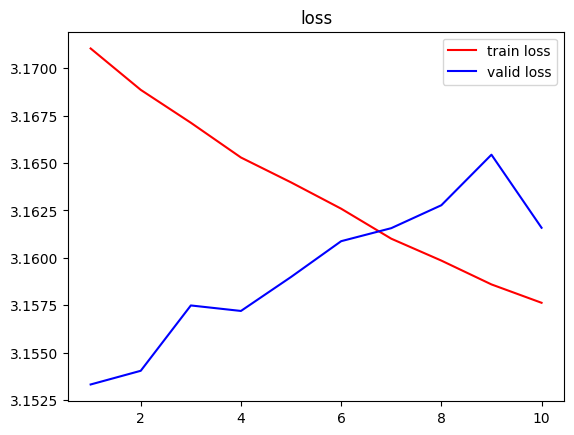

In [13]:
plt.plot(torch.arange(1,EPOCHS+1),train_loss_list,"red",label="train loss")
plt.plot(torch.arange(1,EPOCHS+1),valid_loss_list,"blue",label="valid loss")
plt.legend()
plt.title("loss")
plt.show()

### 4.4 模型

In [14]:
PRIOR_CKPT_PATH = r"..\checkpoints\best_pixelcnn_prior.pt"

prior_cfg = {
    "input_dim": INPUT_DIM,
    "dim":       DIM,
    "n_layers":  LAYERS,
    "n_classes": N_CLASS,
}

best_val_loss = min(valid_loss_list) if len(valid_loss_list) > 0 else float("nan")

if os.path.exists(PRIOR_CKPT_PATH):
    prev_ckpt = torch.load(PRIOR_CKPT_PATH, map_location="cpu", weights_only=False)
    prev_best = prev_ckpt.get("best_loss", float("inf"))
else:
    prev_best = float("inf")

if best_val_loss < prev_best:
    os.makedirs(os.path.dirname(PRIOR_CKPT_PATH), exist_ok=True)
    torch.save({
        "model_state_dict": best_model.state_dict(),
        "config":           prior_cfg,
        "train_loss_list":  train_loss_list,
        "valid_loss_list":  valid_loss_list,
        "best_loss":        best_val_loss,
    }, PRIOR_CKPT_PATH)
    print(f"已保存新的最佳 PixelCNN prior 到: {PRIOR_CKPT_PATH}")
    print(f"  本次 best val loss: {best_val_loss:.6f}  (此前: {prev_best:.6f})")
else:
    print(f"本次 best val loss = {best_val_loss:.6f} 未优于已保存的 {prev_best:.6f}, 不覆盖")

已保存新的最佳 PixelCNN prior 到: ..\checkpoints\best_pixelcnn_prior.pt
  本次 best val loss: 3.153321  (此前: 3.200977)


# 5. 采样

### 5.1 加载最佳先验生成模型

In [15]:
prior_Model=Model.GatedPixelCNN(
    input_dim=INPUT_DIM,
    dim=DIM,
    n_layers=LAYERS,
    n_classes=N_CLASS
)
if os.path.exists(PRIOR_CKPT_PATH):
    prior_ckpt = torch.load(PRIOR_CKPT_PATH, map_location=device, weights_only=False)
    prior_Model.load_state_dict(prior_ckpt["model_state_dict"])
    prior_Model = prior_Model.to(device)
    print(f"已加载已有 PixelCNN prior: {PRIOR_CKPT_PATH}")
    print(f"上次保存的 best val loss: {prior_ckpt.get('best_loss', float('nan')):.6f}")


已加载已有 PixelCNN prior: ..\checkpoints\best_pixelcnn_prior.pt
上次保存的 best val loss: 3.153321


### 5.2 生成标签

In [33]:
labels=torch.arange(100)
shape=(INDICES_H,INDICES_W)
bs=len(labels)
latent=prior_Model.generate(labels,shape,bs,1.0)

In [34]:
print(latent.shape)

torch.Size([100, 16, 16])


### 5.3 生成图片

In [35]:
images=vqvae_model.decode(latent)
images=images.cpu().detach()
print(images.shape)
images=images.permute(0,2,3,1)
for i in range(3):  
    images[:,:,:,i]=images[:,:,:,i]*std[i]+mean[i]

torch.Size([100, 3, 64, 64])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.046352..1.0698581].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.044317156..0.93008876].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06298074..0.58554316].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.01720807..0.95053065].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.005570084..1.0552392].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.023152024..0.8829876].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [

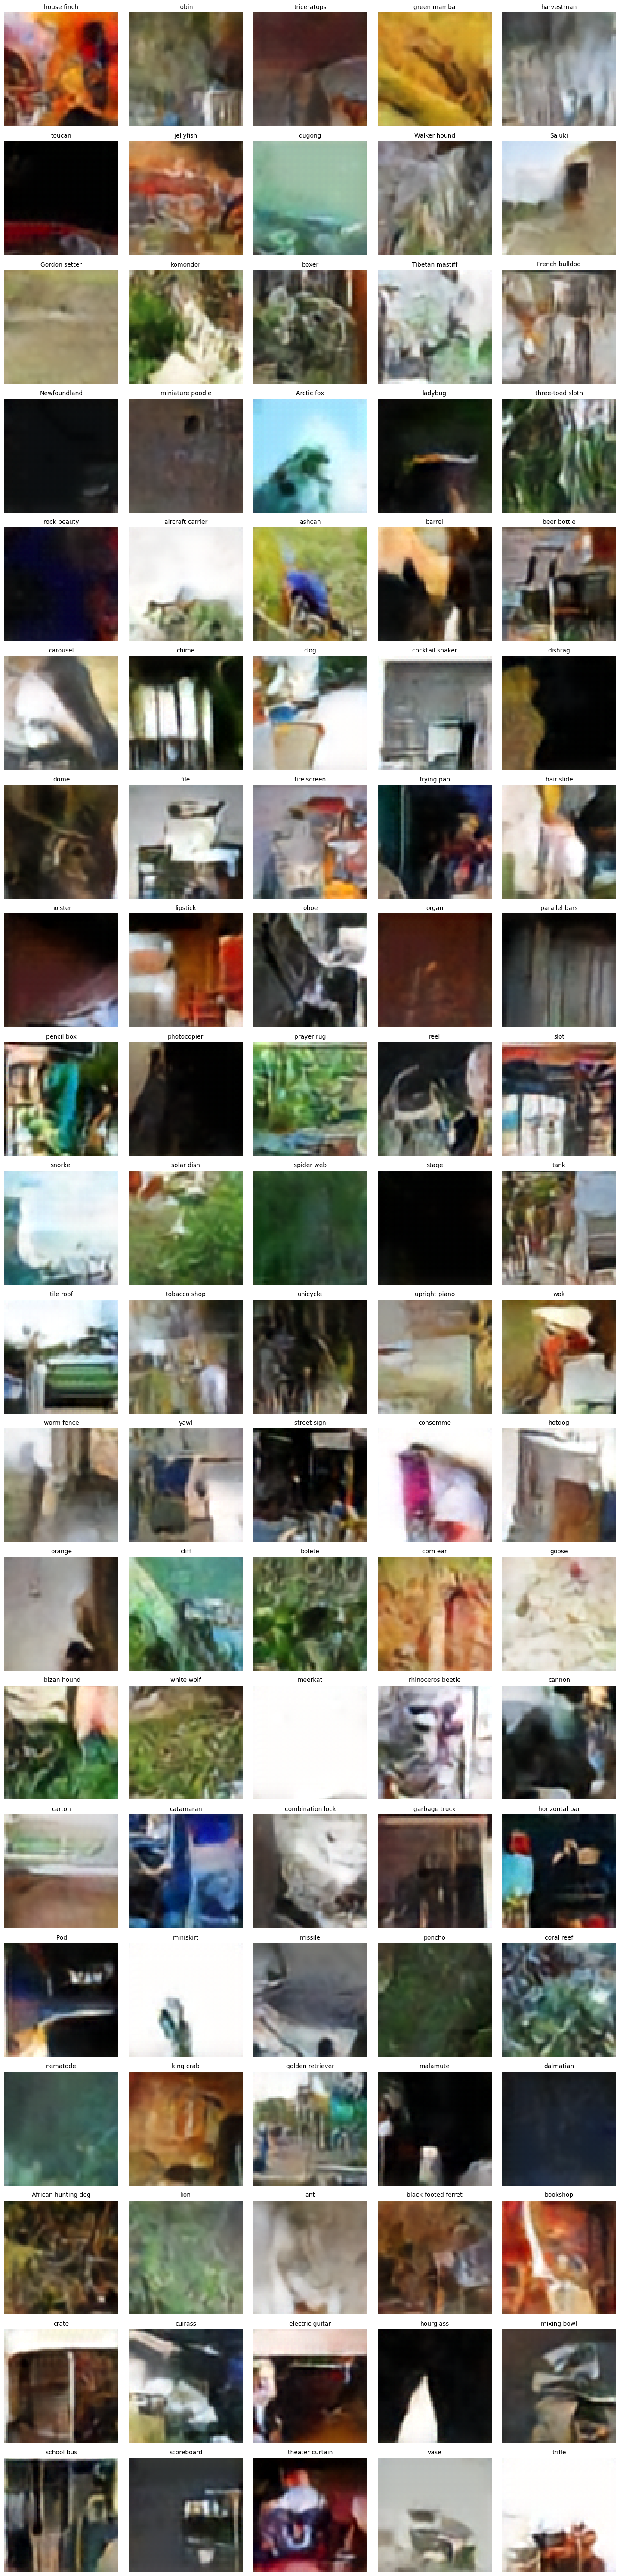

In [36]:

plt.figure(figsize=(15, 60))  

for i in range(bs):
    plt.subplot(20, 5, i+1)  # 20行5列布局不变
    plt.imshow(images[i])
    plt.axis("off")
    # 缩小标题字号，避免文字重叠
    plt.title(Mini_ImageNet_map[labels[i].item()], fontsize=10)

# 调整子图横向、纵向空隙，tight_layout自动适配边距
plt.subplots_adjust(wspace=0.08, hspace=0.3)
plt.tight_layout()
plt.show()

# 6. 原因分析
这里统计vqvae编码出来的索引图的码本使用率和pixelcnn生成的索引图的码本使用率

### 6.1 统计VQ-VAE码本使用率

In [34]:
vqvae_code_usage = torch.bincount(
    all_indices.flatten(),
    minlength=EMBEDDING_DIM
).cpu().float()
total_use = vqvae_code_usage.sum().item()
vqvae_code_usage/=total_use

### 6.2 统计PixelCNN生成的索引图的码本利用率

In [35]:
generate_labels = torch.arange(100).repeat(10)  # shape: [10000]
total_samples = 1000  # 总生成数量
batch_size = 10      # 分批大小（可自定义，比如50/200，能整除10000即可）

# 2. 拆分标签为小批次（关键：把10000个标签切成100个批次，每批10个）
label_batches = generate_labels.split(batch_size)

# 3. 初始化列表，存储每一批生成的结果
all_generate_indices = []

# 4. ✅ tqdm进度条包裹循环，逐批生成
for batch_labels in tqdm(label_batches, total=len(label_batches), desc="生成进度"):
    # 逐批调用你的 prior_Model.generate（参数和你完全一致）
    batch_indices = prior_Model.generate(
        batch_labels,    # 传入当前批次的标签
        shape,           # 你的生成形状参数
        batch_size,      # 批次大小（替换原有的10000）
        1.00             # 温度参数
    )
    # 收集当前批次结果
    all_generate_indices.append(batch_indices)

# 5. 拼接所有批次，得到最终的 10000 个生成结果
generate_indices = torch.cat(all_generate_indices, dim=0)

print(f"\n生成完成！最终形状: {generate_indices.shape}")  # 输出: torch.Size([10000, ...])

生成进度:   0%|          | 0/100 [00:05<?, ?it/s]


KeyboardInterrupt: 

In [36]:
pixelcnn_code_usage=torch.bincount(
    generate_indices.flatten(),
    minlength=EMBEDDING_DIM
).cpu().float()
total_use = pixelcnn_code_usage.sum().item()
pixelcnn_code_usage/=total_use

### 6.3 绘图

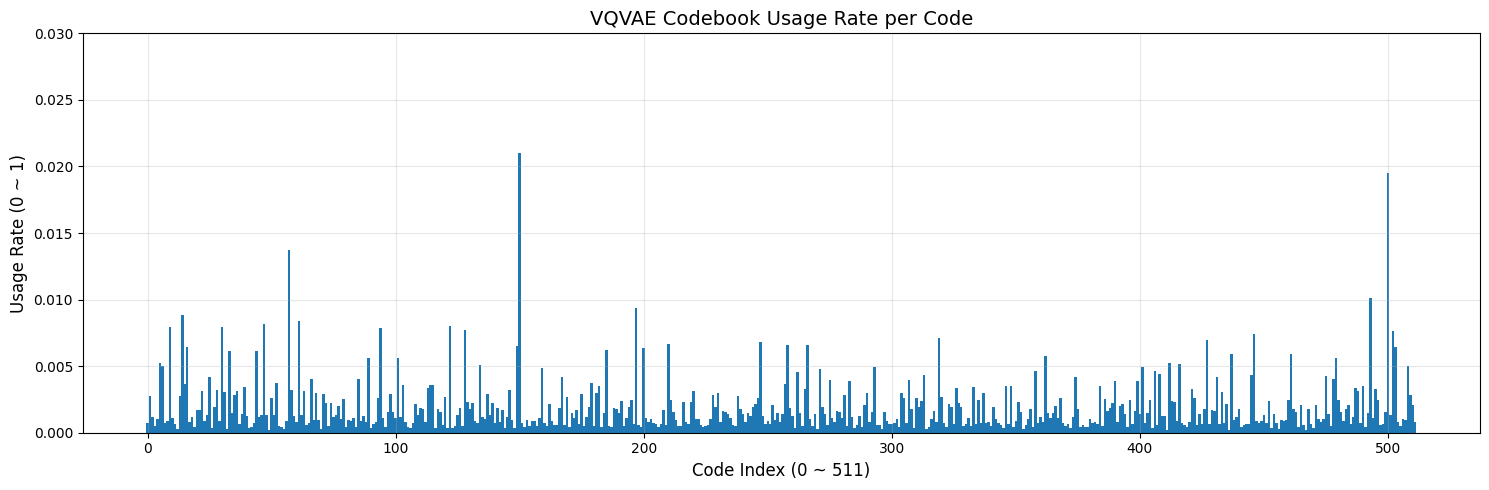

In [37]:
plt.figure(figsize=(15, 5))

# 画柱状图（最清晰）
plt.bar(
    x=range(NUM_EMBEDDINGS),  # X轴：0,1,2,...,511
    height=vqvae_code_usage.numpy(),  # Y轴：每个码本的使用率
    width=1,
    color='#1f77b4'
)

# 轴标签（严格按你要的写）
plt.xlabel("Code Index (0 ~ 511)", fontsize=12)
plt.ylabel("Usage Rate (0 ~ 1)", fontsize=12)
plt.title("VQVAE Codebook Usage Rate per Code", fontsize=14)

# Y轴范围固定 0~1
plt.ylim(0, 0.03)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

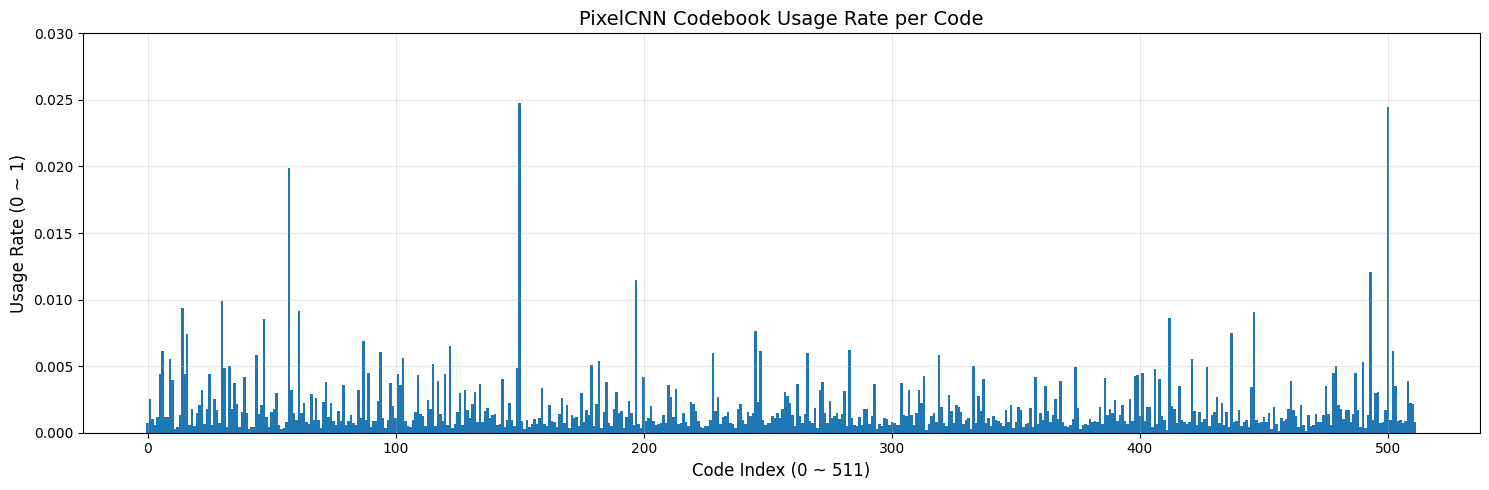

In [38]:
plt.figure(figsize=(15, 5))

# 画柱状图（最清晰）
plt.bar(
    x=range(NUM_EMBEDDINGS),  # X轴：0,1,2,...,511
    height=pixelcnn_code_usage.numpy(),  # Y轴：每个码本的使用率
    width=1,
    color='#1f77b4'
)

# 轴标签（严格按你要的写）
plt.xlabel("Code Index (0 ~ 511)", fontsize=12)
plt.ylabel("Usage Rate (0 ~ 1)", fontsize=12)
plt.title("PixelCNN Codebook Usage Rate per Code", fontsize=14)

# Y轴范围固定 0~1
plt.ylim(0, 0.03)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 算一下方差

In [39]:
vqvae_std=vqvae_code_usage.std()
pixelcnn_std=pixelcnn_code_usage.std()

print(f"VQ-VAE std = {vqvae_std:.6f}")
print(f"PixelCNN std = {pixelcnn_std:.6f}")

VQ-VAE std = 0.002157
PixelCNN std = 0.002395


### 6.4 差值

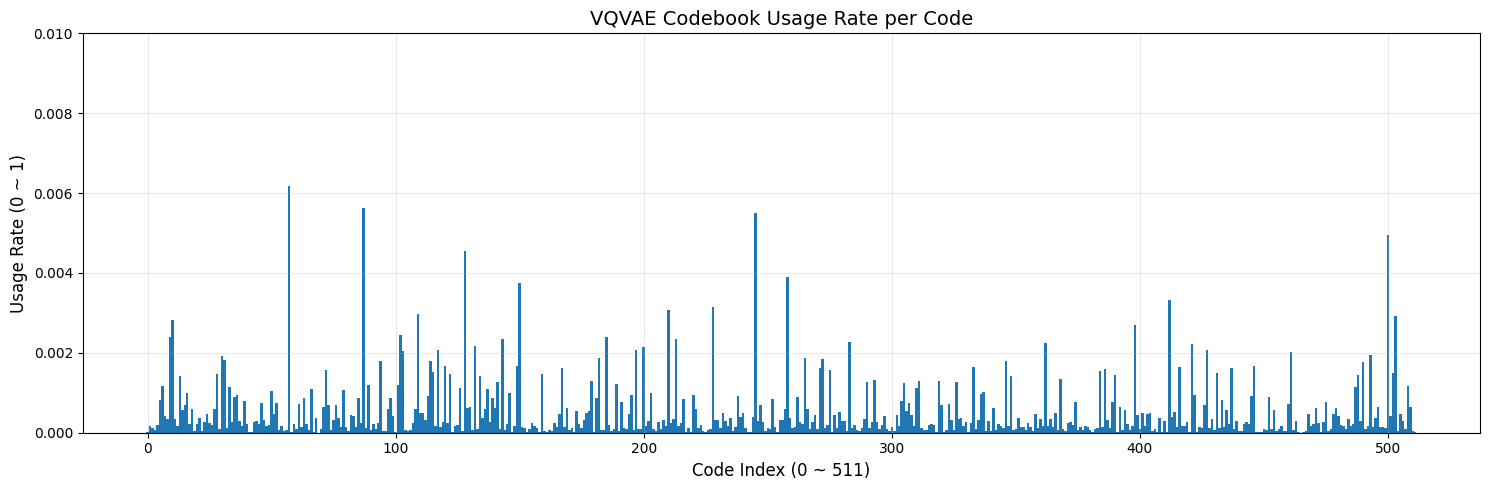

In [41]:
divide=torch.abs(vqvae_code_usage-pixelcnn_code_usage)

plt.figure(figsize=(15, 5))

# 画柱状图（最清晰）
plt.bar(
    x=range(NUM_EMBEDDINGS),  # X轴：0,1,2,...,511
    height=divide.numpy(),  # Y轴：每个码本的使用率
    width=1,
    color='#1f77b4'
)

# 轴标签（严格按你要的写）
plt.xlabel("Code Index (0 ~ 511)", fontsize=12)
plt.ylabel("Usage Rate (0 ~ 1)", fontsize=12)
plt.title("VQVAE Codebook Usage Rate per Code", fontsize=14)

# Y轴范围固定 0~1
plt.ylim(0, 0.01)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
